In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('spam.csv',encoding='latin-1')

In [3]:
df.nunique()

,0
v1,2
v2,5169
Unnamed: 2,43
Unnamed: 3,10
Unnamed: 4,5


In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [6]:
df.shape

(5572, 5)

In [7]:
df.duplicated().sum()

np.int64(403)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.shape

(5169, 5)

In [10]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5126
Unnamed: 3,5159
Unnamed: 4,5164


In [11]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [12]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


##label encode V2 and use nlp tokenization of v2


In [13]:
df.rename(columns={'v1':'is_spam','v2':'text'},inplace=True)

In [14]:
df['is_spam'].value_counts()

,count
is_spam,
ham,4516
spam,653


In [15]:
df['is_spam']=df['is_spam'].map({'ham':0,'spam':1})

In [16]:
df.head()

,is_spam,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [17]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [18]:
def remove_punc(text):
  nonP_txt="".join([char for char in text if char not in string.punctuation])
  return nonP_txt
df['text_clean']=df['text'].apply(lambda x: remove_punc(x))

In [19]:
df.head()

,is_spam,text,text_clean
0,0,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...
1,0,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...


In [20]:
import re
def tokenize(text):
  tokens=re.split("\W+",text) #split by word character
  return tokens
df['text_tokenize']=df['text_clean'].apply(lambda x: tokenize(x))

<>:3: SyntaxWarning: invalid escape sequence '\W'
<>:3: SyntaxWarning: invalid escape sequence '\W'
/tmp/ipykernel_6595/3558744528.py:3: SyntaxWarning: invalid escape sequence '\W'
  tokens=re.split("\W+",text) #split by word character


In [21]:
df.head()

,is_spam,text,text_clean,text_tokenize
0,0,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,"[Go, until, jurong, point, crazy, Available, o..."
1,0,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,"[Ok, lar, Joking, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,"[Free, entry, in, 2, a, wkly, comp, to, win, F..."
3,0,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,"[U, dun, say, so, early, hor, U, c, already, t..."
4,0,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,"[Nah, I, dont, think, he, goes, to, usf, he, l..."


In [22]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [23]:
def remove_stopwords(token):
  txt=[word for word in token if word not in stopwords.words("english")]
  return txt

In [24]:
df['text_nostop']=df['text_tokenize'].apply(lambda x: remove_stopwords(x))

In [25]:
df.head()

,is_spam,text,text_clean,text_tokenize,text_nostop
0,0,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,"[Go, until, jurong, point, crazy, Available, o...","[Go, jurong, point, crazy, Available, bugis, n..."
1,0,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,"[Ok, lar, Joking, wif, u, oni]","[Ok, lar, Joking, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,"[Free, entry, in, 2, a, wkly, comp, to, win, F...","[Free, entry, 2, wkly, comp, win, FA, Cup, fin..."
3,0,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,"[U, dun, say, so, early, hor, U, c, already, t...","[U, dun, say, early, hor, U, c, already, say]"
4,0,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,"[Nah, I, dont, think, he, goes, to, usf, he, l...","[Nah, I, dont, think, goes, usf, lives, around..."


In [26]:
stopwords.words("english")

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [27]:
from nltk.stem import PorterStemmer
ps=PorterStemmer()
def stemming(t_txt):
  text1=[ps.stem(word) for word in t_txt]
  return text1
df["text_stem"]=df["text_nostop"].apply(lambda x: stemming(x))

In [28]:
df.head()

,is_spam,text,text_clean,text_tokenize,text_nostop,text_stem
0,0,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,"[Go, until, jurong, point, crazy, Available, o...","[Go, jurong, point, crazy, Available, bugis, n...","[go, jurong, point, crazi, avail, bugi, n, gre..."
1,0,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,"[Ok, lar, Joking, wif, u, oni]","[Ok, lar, Joking, wif, u, oni]","[ok, lar, joke, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,"[Free, entry, in, 2, a, wkly, comp, to, win, F...","[Free, entry, 2, wkly, comp, win, FA, Cup, fin...","[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,0,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,"[U, dun, say, so, early, hor, U, c, already, t...","[U, dun, say, early, hor, U, c, already, say]","[u, dun, say, earli, hor, u, c, alreadi, say]"
4,0,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,"[Nah, I, dont, think, he, goes, to, usf, he, l...","[Nah, I, dont, think, goes, usf, lives, around...","[nah, i, dont, think, goe, usf, live, around, ..."


In [29]:
df.columns

Index(['is_spam', 'text', 'text_clean', 'text_tokenize', 'text_nostop',
       'text_stem'],
      dtype='object')

In [30]:
import nltk
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [31]:
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [32]:
wn=nltk.WordNetLemmatizer()
def lemmatizer(t):
    text=[wn.lemmatize(word) for word in t]
    return text
df["txt_lem"]=df["text_stem"].apply(lambda x: lemmatizer(x))

In [33]:
df.head()

,is_spam,text,text_clean,text_tokenize,text_nostop,text_stem,txt_lem
0,0,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,"[Go, until, jurong, point, crazy, Available, o...","[Go, jurong, point, crazy, Available, bugis, n...","[go, jurong, point, crazi, avail, bugi, n, gre...","[go, jurong, point, crazi, avail, bugi, n, gre..."
1,0,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,"[Ok, lar, Joking, wif, u, oni]","[Ok, lar, Joking, wif, u, oni]","[ok, lar, joke, wif, u, oni]","[ok, lar, joke, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,"[Free, entry, in, 2, a, wkly, comp, to, win, F...","[Free, entry, 2, wkly, comp, win, FA, Cup, fin...","[free, entri, 2, wkli, comp, win, fa, cup, fin...","[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,0,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,"[U, dun, say, so, early, hor, U, c, already, t...","[U, dun, say, early, hor, U, c, already, say]","[u, dun, say, earli, hor, u, c, alreadi, say]","[u, dun, say, earli, hor, u, c, alreadi, say]"
4,0,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,"[Nah, I, dont, think, he, goes, to, usf, he, l...","[Nah, I, dont, think, goes, usf, lives, around...","[nah, i, dont, think, goe, usf, live, around, ...","[nah, i, dont, think, goe, usf, live, around, ..."


In [34]:
df.rename(columns={"txt_lem": "transformed_text"}, inplace=True)

In [35]:
from wordcloud import WordCloud
wc=WordCloud(width=500, height=500, min_font_size=10,background_color="white")
#

In [36]:
spam_words = ' '.join(df[df['is_spam'] == 1]['transformed_text'].astype(str))
spam_wc=wc.generate(spam_words)

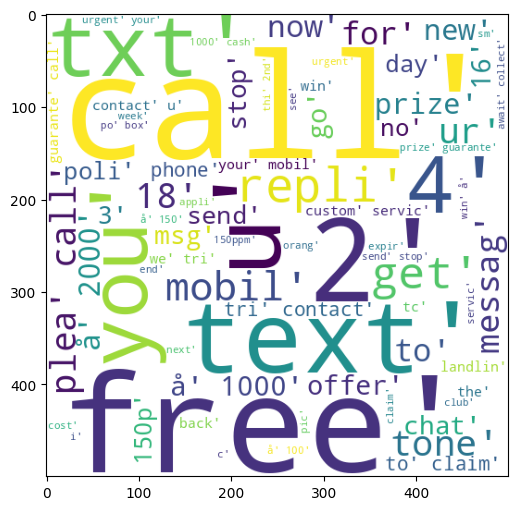

In [37]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [38]:
ham_words = ' '.join(df[df['is_spam'] == 0]['transformed_text'].astype(str))

In [39]:
ham_wc=wc.generate(ham_words)

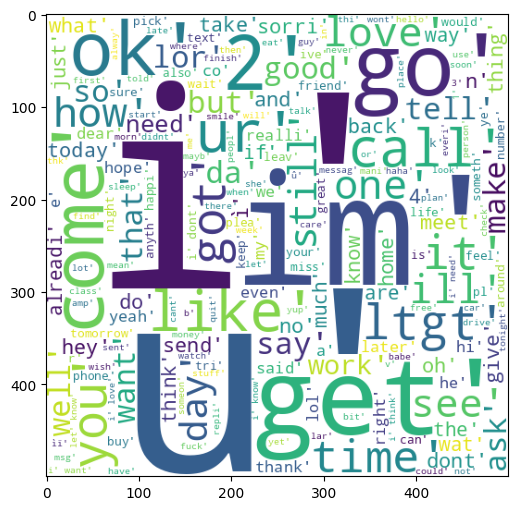

In [40]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [41]:
from sklearn.feature_extraction.text import CountVectorizer

In [42]:
cv=CountVectorizer()

In [43]:
df['transformed_text'] = df['transformed_text'].apply(lambda x: " ".join(x) if isinstance(x, list) else x)
X=cv.fit_transform(df['transformed_text']).toarray()

In [44]:
X.shape

(5169, 8078)

In [45]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [46]:
y=df['is_spam'].values

In [47]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=2)

In [50]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

In [51]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [52]:
bnb.fit(X_train, y_train)
y_pred_bnb=bnb.predict(X_test)

In [53]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
accuracy_score(y_test, y_pred_bnb)
precision_score(y_test, y_pred_bnb)

0.9824561403508771

In [54]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100, random_state=42)

In [55]:
rf.fit(X_train, y_train)
y_pred_rf=rf.predict(X_test)

In [56]:
precision_score(y_test, y_pred_rf)

0.9907407407407407

In [57]:
from sklearn.svm import SVC

In [58]:
svm=SVC(kernel='rbf', C=1, class_weight='balanced')

In [59]:
svm.fit(X_train, y_train)


SVC(C=1, class_weight='balanced')

In [60]:
y_pred_svm=svm.predict(X_test)
confusion_matrix(y_test, y_pred_svm)

array([[895,   1],
       [ 27, 111]])

In [61]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       896
           1       0.99      0.80      0.89       138

    accuracy                           0.97      1034
   macro avg       0.98      0.90      0.94      1034
weighted avg       0.97      0.97      0.97      1034



In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [63]:
tfidf=TfidfVectorizer()

In [64]:
X=tfidf.fit_transform(df['transformed_text']).toarray()

In [65]:
y=df['is_spam'].values

In [66]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [67]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(confusion_matrix(y_test,y_pred1))
print(classification_report(y_test, y_pred1))

[[795 101]
 [ 22 116]]
              precision    recall  f1-score   support

           0       0.97      0.89      0.93       896
           1       0.53      0.84      0.65       138

    accuracy                           0.88      1034
   macro avg       0.75      0.86      0.79      1034
weighted avg       0.91      0.88      0.89      1034



In [68]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(confusion_matrix(y_test,y_pred2))
print(classification_report(y_test, y_pred2))

[[896   0]
 [ 45  93]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       896
           1       1.00      0.67      0.81       138

    accuracy                           0.96      1034
   macro avg       0.98      0.84      0.89      1034
weighted avg       0.96      0.96      0.95      1034



In [69]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(confusion_matrix(y_test,y_pred3))
print(classification_report(y_test,y_pred3))

[[894   2]
 [ 26 112]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       896
           1       0.98      0.81      0.89       138

    accuracy                           0.97      1034
   macro avg       0.98      0.90      0.94      1034
weighted avg       0.97      0.97      0.97      1034



In [70]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features = 3000)

X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['is_spam'].values

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [71]:
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
bnb = BernoulliNB()
rf = RandomForestClassifier(n_estimators=100, random_state=2)

In [72]:
from sklearn.ensemble import VotingClassifier

In [73]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(confusion_matrix(y_test,y_pred3))
print(classification_report(y_test,y_pred3))

[[896   0]
 [ 16 122]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       896
           1       1.00      0.88      0.94       138

    accuracy                           0.98      1034
   macro avg       0.99      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [74]:
vote=VotingClassifier(estimators=[('svm',svc),('bnb',bnb),('rf',rf)],voting='soft')

In [75]:
stop_words = set(stopwords.words('english'))

def transform_text(text):
    text = text.lower()

    text = ''.join(char for char in text if char not in string.punctuation)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [ps.stem(word) for word in words]

    return " ".join(words)

In [76]:
import pickle
pickle.dump(tfidf,open('spam_vectorizer.pkl','wb'))
pickle.dump(bnb,open('spam_model.pkl','wb'))